# Diabetes Risk Prediction Using Logistic Regression

This project builds a machine learning model to predict diabetes risk using patient diagnostic measurements. The workflow includes data cleaning, exploratory data analysis, feature scaling, model training, evaluation, ROC analysis, and feature selection.

### 1. Business Problem

Early detection of diabetes is important for preventing long-term health complications. 
This project builds a classification model to predict whether a patient has diabetes 
based on diagnostic health measurements such as glucose level, BMI, insulin, and age.

The goal is to develop a machine learning model that can identify individuals at higher 
risk of diabetes and evaluate model performance using classification metrics such as 
accuracy, sensitivity, specificity, and ROC-AUC.

### 2. Dataset Overview

The dataset used in this project is the Pima Indians Diabetes dataset obtained from Kaggle. 
It contains medical diagnostic measurements used to predict whether a patient has diabetes.

The dataset includes 768 observations and 9 variables. The target variable is **Outcome**, 
where 0 indicates no diabetes and 1 indicates diabetes.

Predictor variables include:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3. Exploratory Data Analysis

Initial exploration was performed to understand the dataset structure, variable types, 
and overall characteristics before building the model.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nVariable types:")
print(df.dtypes)

Number of rows: 768
Number of columns: 9

Variable types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Summary statistics were calculated to understand the distribution of predictor variables and identify potential irregular values before modeling.

In [5]:
summary_stats = df.drop(columns="Outcome").describe().round(2)

summary_stats

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00


Several medical variables contain zero values that are not realistic and may represent missing data. These values are identified before model training.

In [8]:
cols_to_check = ["Glucose", "BloodPressure", "Insulin", "BMI"]

zero_counts = (df[cols_to_check] == 0).sum()

zero_counts

Glucose            5
BloodPressure     35
Insulin          374
BMI               11
dtype: int64

In [9]:
missing_like_rows = (df[cols_to_check] == 0).any(axis=1).sum()
print("Number of observations with missing like values:", missing_like_rows)

Number of observations with missing like values: 376


### 4. Feature Engineering

Numerical predictor variables were standardized to ensure they are on the same scale before training the logistic regression model. This prevents variables with larger magnitudes from dominating the model.

In [24]:
from sklearn.preprocessing import StandardScaler

#Seperate the predictors
x_numeric = df.drop(columns="Outcome") 

#Apply scaling
scaler = StandardScaler() 
x_scaled = scaler.fit_transform(x_numeric)

#Convert back to dataframe
x_scaled_df = pd.DataFrame(x_scaled, columns=x_numeric.columns)

#Combine with target variable
df_scaled = pd.concat([x_scaled_df, df["Outcome"]], axis=1)

df_scaled.head()




,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1


### 5. Train-Test Split

The dataset was split into training and testing sets to evaluate model performance on unseen data. Stratified sampling was used to maintain the class distribution between diabetic and non-diabetic patients.

In [25]:
from sklearn.model_selection import train_test_split

x = df_scaled.drop(columns="Outcome")

y = df_scaled["Outcome"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
print("Training set size:", x_train.shape[0])
print("Test set size:", x_test.shape[0])

Training set size: 576
Test set size: 192


### 6. Model Building

A logistic regression model was trained using the training dataset to predict 
the probability of diabetes based on patient diagnostic measurements.

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=120)

log_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 7. Model Predictions

The trained logistic regression model was used to generate probability predictions for diabetes on the test dataset.

In [23]:
y_prob = log_reg.predict_proba(x_test)

y_prob[:5]

array([[0.56522956, 0.43477044],
       [0.65713802, 0.34286198],
       [0.89750301, 0.10249699],
       [0.55309869, 0.44690131],
       [0.20068093, 0.79931907]])

In [27]:
prob_df = pd.DataFrame(
    y_prob[:5] * 100,
    columns=["No Diabetes (%)", "Diabetes (%)"]
).round(2)

prob_df

,No Diabetes (%),Diabetes (%)
0,56.52,43.48
1,65.71,34.29
2,89.75,10.25
3,55.31,44.69
4,20.07,79.93


### 8. Classification Predictions

Predicted probabilities were converted into binary classifications using a 
0.5 probability threshold.

In [28]:
y_pred = (y_prob[:,1] >= 0.5).astype(int)

y_pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0])

### 9. Model Evaluation

Model accuracy was calculated by comparing predicted outcomes with the actual 
diabetes outcomes in the test dataset.

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2),"%")

Model Accuracy: 73.44 %


### 10. Confusion Matrix

The confusion matrix was used to evaluate model performance by comparing 
predicted diabetes classifications with actual outcomes.

In [33]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[106,  19],
       [ 32,  35]])

In [36]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Sensitivity:", round(sensitivity * 100, 2),"%")
print("Specificity:", round(specificity * 100, 2),"%")

Sensitivity: 52.24 %
Specificity: 84.8 %


### 11. ROC Curve and AUC

The ROC curve was used to evaluate model performance across different probability 
thresholds. The area under the curve (AUC) measures the model’s ability to 
distinguish between diabetic and non-diabetic patients.

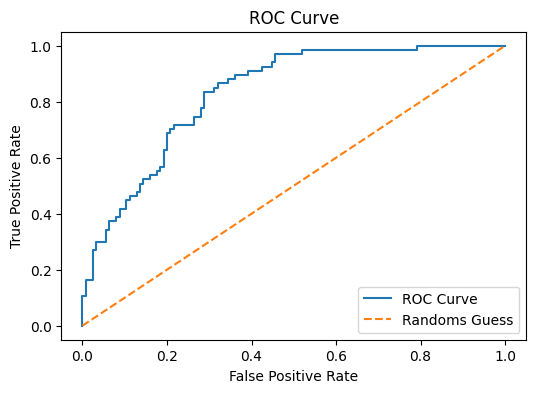

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', label="Randoms Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("images/roc_curve.png")
plt.show()

In [38]:
auc = roc_auc_score(y_test, y_prob[:,1])

print("AUC:", round(auc, 3))

AUC: 0.832


In [39]:
distances = ((1 - tpr)**2 + fpr**2)**0.5

optimal_idx = distances.argmin()
optimal_cutoff = thresholds[optimal_idx]

print("Optimal cutoff:", round(optimal_cutoff, 3))

Optimal cutoff: 0.286


### 12. Feature Selection Analysis

A reduced model was created by removing the Age variable to evaluate its impact on model performance.

In [40]:
selected_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

x_train_reduced = x_train[selected_features]
x_test_reduced = x_test[selected_features]

log_reg_reduced = LogisticRegression(max_iter=120)
log_reg_reduced.fit(x_train_reduced, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
y_prob_reduced = log_reg_reduced.predict_proba(x_test_reduced)

y_pred_reduced = (y_prob_reduced[:, 1] >= optimal_cutoff).astype(int)

accuracy_reduced = accuracy_score(y_test, y_pred_reduced)

print("Reduced Model Accuracy:", round(accuracy_reduced * 100, 2), "%")

Reduced Model Accuracy: 75.52 %


### 13. Key Insights

- The logistic regression model achieved an accuracy of approximately 73%, indicating a solid baseline performance for predicting diabetes. 

- The model was more effective at identifying non-diabetic patients (specificity ~85%) than detecting diabetic cases (sensitivity ~52%), suggesting a tendency to miss some positive cases. 

- The ROC curve and AUC (~0.83) demonstrate that the model has a strong ability to distinguish between diabetic and non-diabetic patients. 

- Lowering the classification threshold improved the model’s ability to detect diabetes, which is important in a healthcare setting where missed cases are more critical than false alarms. 

- Removing the Age variable slightly improved model accuracy (~75.5%), suggesting that it may not contribute meaningful predictive value in this dataset.

### 14. Future Improvements

- Try more advanced models such as Random Forest or Gradient Boosting to see if performance can be improved. 

- Use cross-validation to get a more reliable estimate of how the model performs on different data splits. 

- Explore additional feature engineering to capture more complex relationships between variables. 

- Improve how missing-like values (zeros) are handled, for example by imputing more realistic values. 

- Address class imbalance to improve the model’s ability to detect diabetic cases.